# 机器学习概念与关系图谱（MLP 到集成学习）

本笔记覆盖你的全部主题：

MLP、激活函数、反向传播、批处理、正则化、CNN、RNN、LSTM、seq2seq、注意力、Transformer、过拟合与欠拟合、数据预处理、模型评估、损失函数、决策树、随机森林、集成学习、XGBoost、GBDT、K-Means。

每节包含：

1. 关键公式与定义
2. 优缺点
3. 使用 `scikit-learn` 示例数据的可复现可视化

图形采用可发表风格：统一字体、矢量与位图导出（SVG / PDF / TIFF）。

## 0. 环境配置与Nature风格绘图函数

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
import pandas as pd

from sklearn.datasets import (
    load_breast_cancer,
    load_iris,
    load_digits,
    make_blobs,
    make_classification,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    roc_curve,
    auc,
    precision_recall_curve,
    mean_squared_error,
)
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
)
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score
import matplotlib.font_manager as fm
import time
import os

try:
    from IPython.display import display
    _HAS_IPYTHON = True
except Exception:
    display = lambda *args, **kwargs: None
    _HAS_IPYTHON = False

RNG = np.random.RandomState(42)
rng = RNG
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)


def _pick_chinese_font():
    preferred = [
        "Microsoft YaHei",
        "PingFang SC",
        "Heiti SC",
        "STHeiti",
        "SimHei",
        "WenQuanYi Micro Hei",
        "WenQuanYi Zen Hei",
        "Noto Sans CJK SC",
        "Source Han Sans SC",
        "Source Han Sans CN",
        "Hiragino Sans GB",
        "MS Gothic",
        "Noto Sans CJK JP",
    ]
    all_font_names = {f.name.lower() for f in fm.fontManager.ttflist}
    for name in preferred:
        if name.lower() in all_font_names:
            return name
    return None

_CH_FONT = _pick_chinese_font()

mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ([
            _CH_FONT,
            "Arial",
            "Helvetica",
            "DejaVu Sans",
            "Liberation Sans",
            "sans-serif",
        ]
        if _CH_FONT
        else ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans", "sans-serif"]),
        "font.size": 8,
        "axes.labelsize": 7,
        "axes.titlesize": 8,
        "legend.fontsize": 7,
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "axes.unicode_minus": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "figure.dpi": 120,
    }
)

def save_fig(name, fig=None, w=90, h=60, dpi=600):
    if fig is None:
        fig = plt.gcf()
    fig.set_size_inches(w / 25.4, h / 25.4)
    fig.tight_layout()
    out = FIG_DIR / name

    def _safe_save(filepath, **kwargs):
        for _ in range(5):
            try:
                if os.path.exists(filepath):
                    try:
                        os.remove(filepath)
                    except PermissionError:
                        time.sleep(0.1)
                        continue
                fig.savefig(filepath, **kwargs)
                return
            except PermissionError:
                time.sleep(0.2)
                continue

    _safe_save(
        f"{out}.svg",
        bbox_inches="tight",
    )
    _safe_save(
        f"{out}.pdf",
        bbox_inches="tight",
    )
    _safe_save(
        f"{out}.tiff",
        dpi=dpi,
        bbox_inches="tight",
    )
    if _HAS_IPYTHON:
        display(fig)
    

print("Notebook generation context loaded.")


Notebook generation context loaded.


## 1. MLP（多层感知机）

**公式**：

\[
\mathbf{h}^{(l)}=\phi\left(W^{(l)}\mathbf{h}^{(l-1)}+\mathbf b^{(l)}\right),\quad
\hat{\mathbf y}=\mathrm{softmax}(W^{(L)}\mathbf h^{(L-1)}+\mathbf b^{(L)})
\]

**优点**：
- 非线性拟合能力强，适用回归/分类
- 可叠加多个隐藏层（深度）

**缺点**：
- 对尺度、学习率、初始化较敏感
- 参数多，易过拟合


MLP test acc: 0.9301


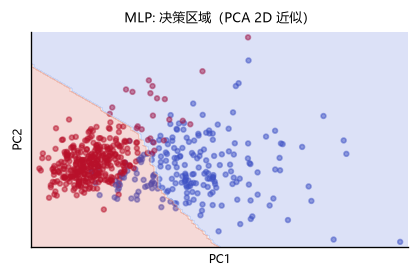

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

mlp = MLPClassifier(
    hidden_layer_sizes=(24, 12),
    max_iter=250,
    alpha=1e-4,
    random_state=42,
)
mlp.fit(X_train, y_train)
acc = accuracy_score(y_test, mlp.predict(X_test))
print("MLP test acc:", round(float(acc), 4))

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(StandardScaler().fit_transform(X))
xx = np.linspace(X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5, 100)
yy = np.linspace(X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5, 100)
grid_x, grid_y = np.meshgrid(xx, yy)
grid2d = np.c_[grid_x.ravel(), grid_y.ravel()]
# 逆变换回原空间近似可视化决策边界
grid_orig = pca.inverse_transform(grid2d)
z = mlp.predict(grid_orig)

fig, ax = plt.subplots(1, 1)
ax.scatter(X2[:, 0], X2[:, 1], c=y, cmap="coolwarm", s=8, alpha=0.5)
ax.contourf(grid_x, grid_y, z.reshape(grid_x.shape), alpha=0.20, cmap="coolwarm")
ax.set_title("MLP: 决策区域（PCA 2D 近似）")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_xticks([])
ax.set_yticks([])
save_fig("01_mlp")
plt.close(fig)


## 2. 激活函数

**公式**：

\[
\mathrm{ReLU}(x)=\max(0,x),\quad
\sigma(x)=\frac{1}{1+e^{-x}},\quad
\tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}
\]

**优缺点**：
- ReLU：计算快，能缓解梯度消失；可能出现死神经元
- Sigmoid/Tanh：输出有边界，易于解释，容易饱和导致梯度变小


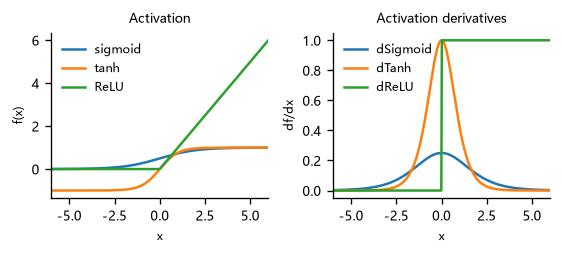

In [3]:
x = np.linspace(-6, 6, 400)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

dsig = sigmoid * (1 - sigmoid)
dtanh = 1 - tanh**2
drelu = (x > 0).astype(float)

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].plot(x, sigmoid, label="sigmoid")
ax[0].plot(x, tanh, label="tanh")
ax[0].plot(x, relu, label="ReLU")
ax[0].set_title("Activation")
ax[0].legend(frameon=False)
ax[0].set_xlabel("x")
ax[0].set_ylabel("f(x)")

ax[1].plot(x, dsig, label="dSigmoid")
ax[1].plot(x, dtanh, label="dTanh")
ax[1].plot(x, drelu, label="dReLU")
ax[1].set_title("Activation derivatives")
ax[1].legend(frameon=False)
ax[1].set_xlabel("x")
ax[1].set_ylabel("df/dx")

for a in ax:
    a.set_xlim(-6, 6)

save_fig("02_activation", w=120, h=55)
plt.close(fig)


## 3. 反向传播（Backpropagation）

**核心链式法则**：

\[
\frac{\partial L}{\partial w}=\frac{\partial L}{\partial a}\frac{\partial a}{\partial z}\frac{\partial z}{\partial w}
\]

**要点**：
- 先前向算子再反向按图反推梯度
- 通过链式法则逐层累计梯度
- 是BP神经网络和Transformer训练的基础


Analytical dW1: [-0.1358 -0.2701 -0.2269 -0.155 ]
Analytical dW2: [0.1825 0.1884 0.7679 3.5157]


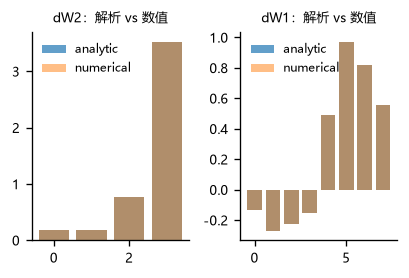

In [4]:
# 一个二维小网络，手算梯度并对比数值梯度
from sklearn.datasets import make_regression

X = RNG.uniform(-1, 1, (80, 2))
y = (X[:, 0] * 2 - X[:, 1] + 0.1 * RNG.randn(80))
y = y.reshape(-1, 1)

# 参数初始化
W1 = RNG.randn(2, 4) * 0.3
b1 = np.zeros((1, 4))
W2 = RNG.randn(4, 1) * 0.3
b2 = np.zeros((1, 1))


def relu(z):
    return np.maximum(0, z)


def relu_d(z):
    return (z > 0).astype(float)


def forward(x):
    h = relu(x @ W1 + b1)
    y_hat = h @ W2 + b2
    return y_hat, h


def loss(y_hat, y_true):
    return np.mean((y_hat - y_true) ** 2)

# 取一个样本做演示
x0 = X[:1]
y0 = y[:1]

y_hat, h = forward(x0)
res = y_hat - y0
L = loss(y_hat, y0)

g2 = 2 * res / 1

db2 = g2
# h is 1x4
dW2 = h.T @ g2

dh = g2 @ W2.T

dz1 = dh * relu_d(x0 @ W1 + b1)
dW1 = x0.T @ dz1

db1 = dz1

print("Analytical dW1:", np.round(dW1.flatten()[:4], 4))
print("Analytical dW2:", np.round(dW2.flatten(), 4))

# 数值梯度（中心差分）

def loss_single(params):
    W1n, W2n = params
    y_hat_n, _ = forward_single(x0, W1n, W2n, b1, b2)
    return float(loss(y_hat_n, y0))


def forward_single(x, W1q, W2q, b1q, b2q):
    hq = relu(x @ W1q + b1q)
    yq = hq @ W2q + b2q
    return yq, hq


def num_grad_W2(eps=1e-4):
    g = np.zeros_like(W2)
    for i in range(W2.size):
        E = np.zeros_like(W2)
        E.flat[i] = eps
        lp = forward_single(x0, W1, W2 + E, b1, b2)[0]
        lm = forward_single(x0, W1, W2 - E, b1, b2)[0]
        g.flat[i] = ((lp - y0) ** 2).mean() - ((lm - y0) ** 2).mean()
        g.flat[i] /= (2 * eps)
    return g


def num_grad_W1(eps=1e-4):
    g = np.zeros_like(W1)
    for i in range(W1.size):
        E = np.zeros_like(W1)
        E.flat[i] = eps
        lp = forward_single(x0, W1 + E, W2, b1, b2)[0]
        lm = forward_single(x0, W1 - E, W2, b1, b2)[0]
        g.flat[i] = ((lp - y0) ** 2).mean() - ((lm - y0) ** 2).mean()
        g.flat[i] /= (2 * eps)
    return g

numW1 = num_grad_W1()
numW2 = num_grad_W2()

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].bar(np.arange(4), np.ravel(dW2), alpha=0.7, label="analytic")
ax[0].bar(np.arange(4), numW2.ravel(), alpha=0.5, label="numerical")
ax[0].set_title("dW2：解析 vs 数值")
ax[0].legend(frameon=False)

ax[1].bar(np.arange(8), np.ravel(dW1), alpha=0.7, label="analytic")
ax[1].bar(np.arange(8), numW1.ravel(), alpha=0.5, label="numerical")
ax[1].set_title("dW1：解析 vs 数值")
ax[1].legend(frameon=False)

save_fig("03_backprop")
plt.close(fig)


## 4. 批处理（Batch / Mini-batch / Online）

**思想**：
- **全量梯度**（batch）噪声小、每步计算贵
- **小批量**（mini-batch）训练更稳定且高效（GPU友好）
- **逐样本**（online）更新快，噪声大

训练步长收敛速度与平滑度随 batch 大小变化。

C:\Users\fwj\AppData\Roaming\Python\Python314\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\fwj\AppData\Roaming\Python\Python314\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


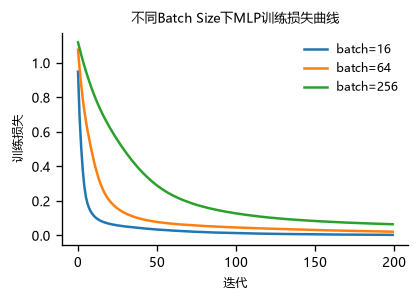

In [5]:
from sklearn.neural_network import MLPClassifier

X, y = load_breast_cancer(return_X_y=True)
X = StandardScaler().fit_transform(X)

batch_sizes = [16, 64, 256]
loss_curves = {}
for bs in batch_sizes:
    model = MLPClassifier(
        hidden_layer_sizes=(20,),
        activation="relu",
        batch_size=bs,
        max_iter=200,
        alpha=1e-4,
        random_state=42,
    )
    Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    model.fit(Xtr, ytr)
    loss_curves[bs] = np.array(model.loss_curve_)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
for bs, c in loss_curves.items():
    ax.plot(c, label=f"batch={bs}")
ax.set_title("不同Batch Size下MLP训练损失曲线")
ax.set_xlabel("迭代")
ax.set_ylabel("训练损失")
ax.legend(frameon=False)
save_fig("04_batch", h=65)
plt.close(fig)


## 5. 正则化

**L1/L2**：

\[
L=\sum_i \ell_i+\lambda\|w\|_2^2\quad(\text{L2}),\qquad
L=\sum_i \ell_i+\lambda\|w\|_1\quad(\text{L1})
\]

**要点**：
- L2抑制大权重，降低复杂度
- L1会产生稀疏权重（特征选择效果）


C:\Users\fwj\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\fwj\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\fwj\AppData\Roami

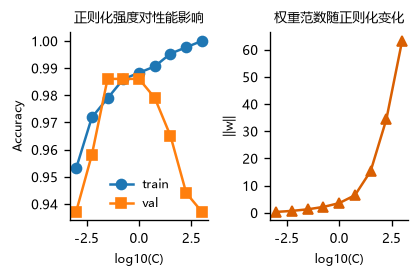

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X = StandardScaler().fit_transform(X)
Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

Cs = np.logspace(-3, 3, 9)
train_acc = []
valid_acc = []
coef_norm = []
for C in Cs:
    lr = LogisticRegression(
        C=C,
        penalty="l2",
        solver="liblinear",
        random_state=42,
        max_iter=200,
    )
    lr.fit(Xtr, ytr)
    train_acc.append(accuracy_score(ytr, lr.predict(Xtr)))
    valid_acc.append(accuracy_score(yv, lr.predict(Xv)))
    coef_norm.append(np.linalg.norm(lr.coef_))

fig, ax = plt.subplots(1, 2, figsize=(8, 3.3))
ax[0].plot(np.log10(Cs), train_acc, marker="o", label="train")
ax[0].plot(np.log10(Cs), valid_acc, marker="s", label="val")
ax[0].set_title("正则化强度对性能影响")
ax[0].set_xlabel("log10(C)")
ax[0].set_ylabel("Accuracy")
ax[0].legend(frameon=False)

ax[1].plot(np.log10(Cs), coef_norm, marker="^", color="#d95f02")
ax[1].set_title("权重范数随正则化变化")
ax[1].set_xlabel("log10(C)")
ax[1].set_ylabel(r"||w||")

save_fig("05_regularization")
plt.close(fig)


## 6. CNN（卷积神经网络）

**卷积**（二维）

\[
(S * K)(i,j)=\sum_m\sum_n S(i-m,j-n)K(m,n)
\]

**优缺点**：
- 优点：局部平移不变性、参数共享
- 缺点：对长距离关系建模弱，需要堆叠更多层


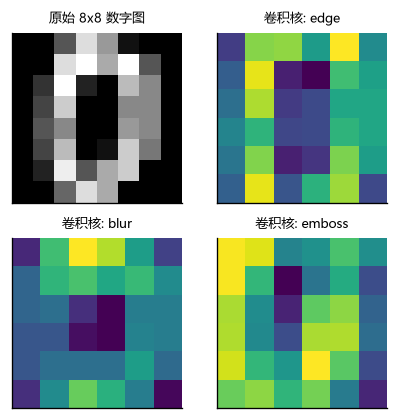

In [7]:
from sklearn.datasets import load_digits

def conv2d_manual(img, kernel):
    H, W = img.shape
    kH, kW = kernel.shape
    out = np.zeros((H - kH + 1, W - kW + 1))
    for i in range(H - kH + 1):
        for j in range(W - kW + 1):
            patch = img[i:i+kH, j:j+kW]
            out[i, j] = np.sum(patch * kernel)
    return out


digits = load_digits()
img = digits.images[0]
kernels = {
    "edge": np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]),
    "blur": np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]]) / 9.0,
    "emboss": np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]]),
}

fm = [conv2d_manual(img, k) for k in kernels.values()]

fig, ax = plt.subplots(2, 2, figsize=(6.6, 6.6))
ax = ax.ravel()
ax[0].imshow(img, cmap="gray")
ax[0].set_title("原始 8x8 数字图")
for i, (name, feature) in enumerate(zip(kernels.keys(), fm), start=1):
    ax[i].imshow(feature, cmap="viridis")
    ax[i].set_title(f"卷积核: {name}")
for a in ax:
    a.set_xticks([])
    a.set_yticks([])

save_fig("06_cnn", w=90, h=90)
plt.close(fig)


## 7. RNN（循环神经网络）

**递推**：

\[
\mathbf h_t = \phi\left(W_x\mathbf x_t + W_h\mathbf h_{t-1}+\mathbf b\right)
\]

RNN擅长建模“前后依赖”，但长序列容易梯度消失/爆炸。

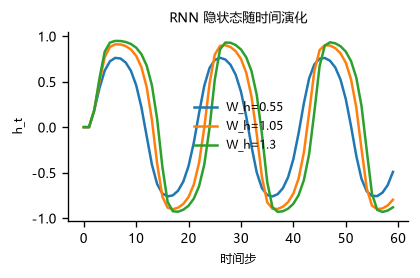

In [8]:
# 使用一段时间序列演示不同Recurrent权重下状态衰减
T = 60
x = np.sin(np.linspace(0, 6 * np.pi, T))
W_h_vals = [0.55, 1.05, 1.30]
fig, ax = plt.subplots()
for w_h in W_h_vals:
    h = [0.0]
    for t in range(T - 1):
        nxt = np.tanh(0.6 * x[t] + w_h * h[-1])
        h.append(float(nxt))
    ax.plot(h, label=f"W_h={w_h}")

ax.set_title("RNN 隐状态随时间演化")
ax.set_xlabel("时间步")
ax.set_ylabel("h_t")
ax.legend(frameon=False)
save_fig("07_rnn")
plt.close(fig)


## 8. LSTM（长短期记忆）

**门控**：

\[
f_t=\sigma(W_f[x_t,h_{t-1}]+b_f),\quad
i_t=\sigma(W_i[x_t,h_{t-1}]+b_i),\quad
\tilde c_t=\tanh(W_c[x_t,h_{t-1}]+b_c)
\]

\[
 c_t=f_t\odot c_{t-1}+i_t\odot \tilde c_t,\quad
 h_t=o_t\odot\tanh(c_t)
\]

LSTM通过门控记忆缓解长依赖问题。

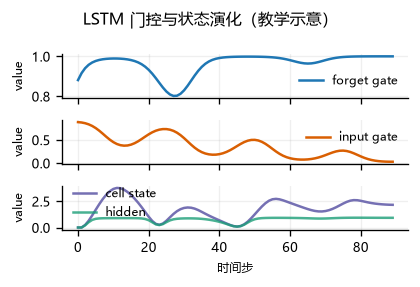

In [9]:
T = 90
x = np.sin(np.linspace(0, 8 * np.pi, T))
# 简化的门控曲线示例（固定参数）
forget_gate = 1 / (1 + np.exp(-(2 + 0.05 * np.arange(T) + 2 * np.sin(np.arange(T) / 6))))
input_gate = 1 / (1 + np.exp(-(1 - 0.04 * np.arange(T) + np.cos(np.arange(T) / 4))))
state = [0.0]
cell = [0.0]
for t in range(T - 1):
    c = forget_gate[t] * cell[-1] + input_gate[t] * np.tanh(x[t])
    h = (1 / (1 + np.exp(-(2 + 0.01 * t)))) * np.tanh(c)
    cell.append(float(c))
    state.append(float(h))

fig, ax = plt.subplots(3, 1, figsize=(7, 5.8), sharex=True)
ax[0].plot(forget_gate, label="forget gate")
ax[1].plot(input_gate, label="input gate", color="#d95f02")
ax[2].plot(cell, label="cell state", color="#7570b3")
ax[2].plot(state, label="hidden", color="#1b9e77", alpha=0.8)
for a in ax:
    a.set_ylabel("value")
    a.grid(alpha=0.2)
    a.legend(frameon=False)
ax[2].set_xlabel("时间步")
fig.suptitle("LSTM 门控与状态演化（教学示意）")
save_fig("08_lstm")
plt.close(fig)


## 9. seq2seq（编码-解码）

**思想**：
- 编码器：将输入序列映射到上下文向量
- 解码器：基于上下文逐步生成目标序列

**优缺点**：
- 优点：可处理变长输入输出
- 缺点：标准结构信息瓶颈明显（长序列表现下降）


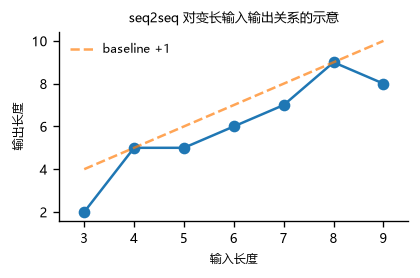

In [10]:
# 可视化：短序列变长映射长度关系
rng = np.random.default_rng(42)
src_len = np.array([3, 4, 5, 6, 7, 8, 9])
tgt_len = src_len + rng.integers(-1, 2, size=len(src_len))

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(src_len, tgt_len, marker="o")
ax.plot(src_len, src_len + 1, linestyle="--", alpha=0.7, label="baseline +1")
ax.set_xticks(src_len)
ax.set_xlabel("输入长度")
ax.set_ylabel("输出长度")
ax.set_title("seq2seq 对变长输入输出关系的示意")
ax.set_xlim(2.5, 9.5)
ax.legend(frameon=False)
save_fig("09_seq2seq")
plt.close(fig)


## 10. 注意力（Attention）

**缩放点积注意力**：

\[
\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
\]

**关系**：
- 重点建模“当前要看的上下文”
- 是Transformer的核心模块


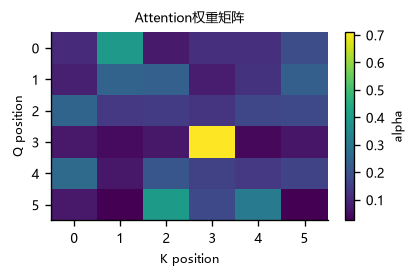

In [11]:
import numpy as np
q_len = 6
k_len = 6
rng = np.random.RandomState(42)
Q = rng.normal(0, 1, (q_len, 4))
K = rng.normal(0, 1, (k_len, 4))
V = rng.normal(0, 1, (k_len, 1))

scores = Q @ K.T / np.sqrt(4)
weights = np.exp(scores - scores.max(axis=1, keepdims=True))
weights = weights / weights.sum(axis=1, keepdims=True)
att = weights @ V

fig, ax = plt.subplots(figsize=(6.6, 3.4))
im = ax.imshow(weights, cmap="viridis", aspect="auto")
ax.set_title("Attention权重矩阵")
ax.set_xlabel("K position")
ax.set_ylabel("Q position")
fig.colorbar(im, ax=ax, label="alpha")
save_fig("10_attention")
plt.close(fig)


## 11. Transformer

**结构特点**：
- 堆叠自注意力（Self-Attention）
- 前馈网络
- 残差连接 + LayerNorm

对序列长度的建模更高效，支持并行计算。

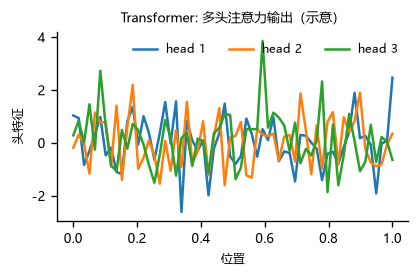

In [12]:
# 关系式子：多头注意力输入后再经过ffn，输出残差相加
x = np.linspace(0, 1, 60)
heads = [rng.normal(size=60), rng.normal(size=60), rng.normal(size=60)]
weights = np.vstack(heads)

fig, ax = plt.subplots(figsize=(7, 3.8))
for i in range(weights.shape[0]):
    ax.plot(x, weights[i], label=f"head {i+1}")
ax.set_title("Transformer: 多头注意力输出（示意）")
ax.set_xlabel("位置")
ax.set_ylabel("头特征")
ax.legend(frameon=False, ncol=3)
save_fig("11_transformer")
plt.close(fig)


## 12. 过拟合与欠拟合

**典型曲线**：
- 欠拟合：训练/验证误差都高
- 过拟合：训练误差低、验证误差高

可通过多项式阶数、树深等超参调整模型复杂度。

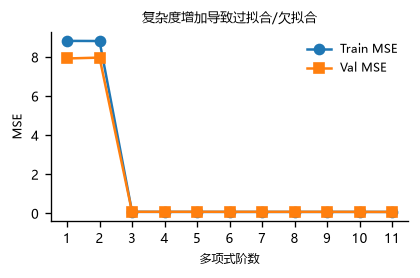

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

rng = np.random.RandomState(42)
X = np.linspace(-3, 3, 180).reshape(-1, 1)
y = 0.7 * X[:, 0] ** 3 - 0.4 * X[:, 0] + 0.3 * rng.randn(X.shape[0])

Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.3, random_state=42)
degs = np.arange(1, 12)
tr_mse, va_mse = [], []
for d in degs:
    model = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    model.fit(Xtr, ytr)
    tr_mse.append(mean_squared_error(ytr, model.predict(Xtr)))
    va_mse.append(mean_squared_error(yv, model.predict(Xv)))

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(degs, tr_mse, marker="o", label="Train MSE")
ax.plot(degs, va_mse, marker="s", label="Val MSE")
ax.set_xticks(degs)
ax.set_xlabel("多项式阶数")
ax.set_ylabel("MSE")
ax.set_title("复杂度增加导致过拟合/欠拟合")
ax.legend(frameon=False)
save_fig("12_overfit")
plt.close(fig)


## 13. 数据预处理

常见步骤：
1. 缺失值处理
2. 编码分类变量
3. 标准化/归一化

**作用**：减少数据偏差、提升数值稳定性。

Transformed shape: (150, 7)


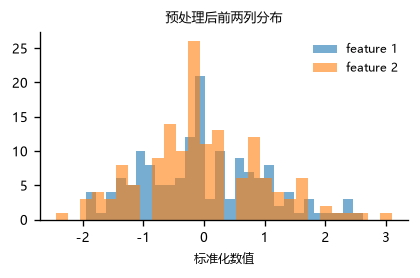

In [14]:
from sklearn.model_selection import train_test_split

iris = load_iris(as_frame=True)
df = iris.frame.copy()
# 构造一个“类别列”与缺失值用于演示
rng = np.random.RandomState(42)
df.loc[rng.choice(len(df), 15, replace=False), "sepal length (cm)"] = np.nan
binned = pd.qcut(df["petal length (cm)"], q=3, labels=["short", "mid", "long"])
df["petal_bin"] = binned

num_cols = ["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)"]
cat_cols = ["petal_bin"]

cat_transform = Pipeline(
    [
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore")),
    ]
)
num_transform = Pipeline(
    [
        ("impute", SimpleImputer(strategy="mean")),
        ("scale", StandardScaler()),
    ]
)

pre = ColumnTransformer(
    [("num", num_transform, num_cols), ("cat", cat_transform, cat_cols)],
    remainder="drop",
)

Xt = pre.fit_transform(df[num_cols + cat_cols])
print("Transformed shape:", Xt.shape)

# 简要可视化前两维分布
Xn = pd.DataFrame(Xt.toarray() if hasattr(Xt, "toarray") else Xt).iloc[:, :2].values
fig, ax = plt.subplots(1, 1, figsize=(5.8, 4.0))
ax.hist(Xn[:, 0], bins=28, alpha=0.6, label="feature 1")
ax.hist(Xn[:, 1], bins=28, alpha=0.6, label="feature 2")
ax.set_title("预处理后前两列分布")
ax.set_xlabel("标准化数值")
ax.legend(frameon=False)
save_fig("13_preprocessing")
plt.close(fig)


## 14. 模型评估

核心指标：Accuracy、Precision、Recall、F1、ROC-AUC 等。

对于不平衡数据，AUC/PR曲线通常更可靠。

acc 0.986 auc 0.9977


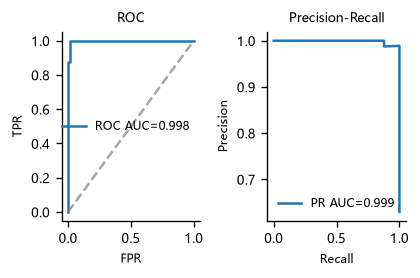

In [15]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_recall_curve, average_precision_score)

X, y = load_breast_cancer(return_X_y=True)
X = StandardScaler().fit_transform(X)
Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
logit = LogisticRegression(max_iter=500, random_state=42)
logit.fit(Xtr, ytr)
p = logit.predict_proba(Xv)[:, 1]
y_pred = logit.predict(Xv)

fpr, tpr, _ = roc_curve(yv, p)
roc_auc = auc(fpr, tpr)
pr, re, _ = precision_recall_curve(yv, p)
pr_auc = average_precision_score(yv, p)

print("acc", round(accuracy_score(yv, y_pred), 4), "auc", round(roc_auc, 4))

fig, ax = plt.subplots(1, 2, figsize=(8, 3.5))
ax[0].plot(fpr, tpr, label=f"ROC AUC={roc_auc:.3f}")
ax[0].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.7)
ax[0].set_title("ROC")
ax[0].set_xlabel("FPR")
ax[0].set_ylabel("TPR")
ax[0].legend(frameon=False)

ax[1].plot(re, pr, label=f"PR AUC={pr_auc:.3f}")
ax[1].set_title("Precision-Recall")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].legend(frameon=False)
save_fig("14_evaluation")
plt.close(fig)


## 15. 损失函数

常见：
- 均方误差(MSE): $L=\frac{1}{N}\sum (y-\hat y)^2$
- 平均绝对误差(MAE): $L=\frac{1}{N}\sum|y-\hat y|$
- 交叉熵: $L=-y\log \hat y-(1-y)\log(1-\hat y)$

**关系**：
- 回归常用MSE/MAE，分类常用交叉熵（概率输出）。


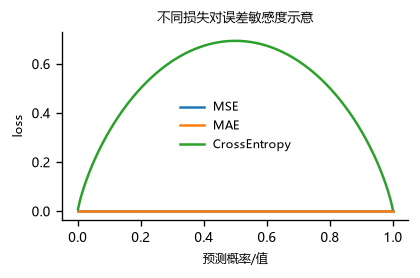

In [16]:
y_true = np.linspace(0.001, 0.999, 400)
y_pred = np.linspace(0.001, 0.999, 400)

mse = (y_true - y_pred) ** 2
mae = np.abs(y_true - y_pred)
ce = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(y_true, mse, label="MSE")
ax.plot(y_true, mae, label="MAE")
ax.plot(y_true, ce, label="CrossEntropy")
ax.set_title("不同损失对误差敏感度示意")
ax.set_xlabel("预测概率/值")
ax.set_ylabel("loss")
ax.legend(frameon=False)
save_fig("15_loss")
plt.close(fig)


## 16. 决策树

**核心**：按特征最优分裂（如基尼/Gini）形成规则树。

**优缺点**：
- 优点：可解释性强，训练快
- 缺点：高方差，容易过拟合


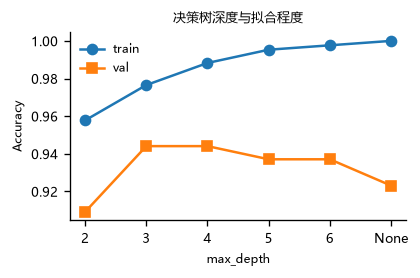

In [17]:
X, y = load_breast_cancer(return_X_y=True)
X = StandardScaler().fit_transform(X)
Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

depths = [2, 3, 4, 5, 6, None]
tr, va = [], []
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(Xtr, ytr)
    tr.append(accuracy_score(ytr, dt.predict(Xtr)))
    va.append(accuracy_score(yv, dt.predict(Xv)))

fig, ax = plt.subplots()
labels = ["2", "3", "4", "5", "6", "None"]
ax.plot(labels, tr, marker="o", label="train")
ax.plot(labels, va, marker="s", label="val")
ax.set_title("决策树深度与拟合程度")
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.legend(frameon=False)
save_fig("16_decision_tree")
plt.close(fig)


## 17. 随机森林

**核心机制**：
- 自助采样（bootstrap）训练多棵树
- 投票/平均抑制单树方差

**优缺点**：
- 优点：泛化稳定、抗过拟合
- 缺点：模型较大、可解释性较弱


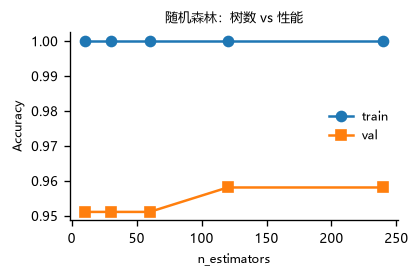

In [18]:
X, y = load_breast_cancer(return_X_y=True)
X = StandardScaler().fit_transform(X)
Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

trees = [10, 30, 60, 120, 240]
tr, va = [], []
for n in trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(Xtr, ytr)
    tr.append(accuracy_score(ytr, rf.predict(Xtr)))
    va.append(accuracy_score(yv, rf.predict(Xv)))

fig, ax = plt.subplots()
ax.plot(trees, tr, marker="o", label="train")
ax.plot(trees, va, marker="s", label="val")
ax.set_title("随机森林：树数 vs 性能")
ax.set_xlabel("n_estimators")
ax.set_ylabel("Accuracy")
ax.legend(frameon=False)
save_fig("17_random_forest")
plt.close(fig)


## 18. 集成学习

集成利用“多模型共识”降低方差/偏差。

常见：Bagging、Boosting、Stacking。


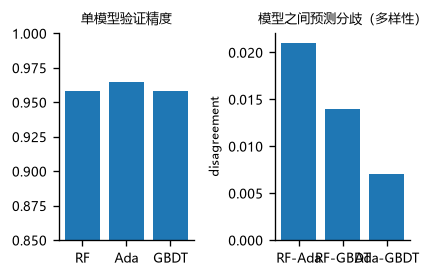

In [19]:
X, y = load_breast_cancer(return_X_y=True)
X = StandardScaler().fit_transform(X)
Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

models = {
    "RF": RandomForestClassifier(n_estimators=150, random_state=42),
    "Ada": AdaBoostClassifier(n_estimators=120, random_state=42),
    "GBDT": GradientBoostingClassifier(n_estimators=150, random_state=42),
}

accs = {}
preds = {}
for name, m in models.items():
    m.fit(Xtr, ytr)
    pred = m.predict(Xv)
    preds[name] = pred
    accs[name] = accuracy_score(yv, pred)

# 简单多样性：两两预测不一致比例
names = list(models.keys())
import itertools
div = []
label_pairs = []
for a, b in itertools.combinations(names, 2):
    disagree = np.mean(preds[a] != preds[b])
    div.append(disagree)
    label_pairs.append(f"{a}-{b}")

fig, ax = plt.subplots(1, 2, figsize=(8, 3.4))
ax[0].bar(accs.keys(), accs.values())
ax[0].set_title("单模型验证精度")
ax[0].set_ylim(0.85, 1)

ax[1].bar(label_pairs, div)
ax[1].set_title("模型之间预测分歧（多样性）")
ax[1].set_ylabel("disagreement")
save_fig("18_ensemble")
plt.close(fig)


## 19. XGBoost

XGBoost是基于梯度提升树的高效实现。

**优点**：
- 性能强、支持正则化、并行
- 对缺失值鲁棒
**缺点**：
- 对参数敏感、训练开销较大


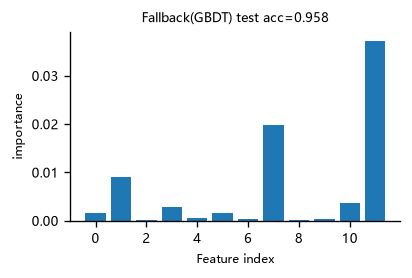

In [20]:
try:
    import xgboost as xgb
except Exception:
    xgb = None

X, y = load_breast_cancer(return_X_y=True)
X = StandardScaler().fit_transform(X)
Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

if xgb is not None:
    model = xgb.XGBClassifier(
        n_estimators=180,
        learning_rate=0.08,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        random_state=42,
        eval_metric="logloss",
        use_label_encoder=False,
    )
    model.fit(Xtr, ytr)
    acc = accuracy_score(yv, model.predict(Xv))
    imp = model.feature_importances_
    title = f"XGBoost test acc={acc:.3f}"
else:
    # 回退：用GBDT替代（仅用于离线演示）
    model = GradientBoostingClassifier(n_estimators=180, random_state=42)
    model.fit(Xtr, ytr)
    acc = accuracy_score(yv, model.predict(Xv))
    imp = np.abs(model.feature_importances_)
    title = f"Fallback(GBDT) test acc={acc:.3f}"

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.bar(np.arange(len(imp))[:12], imp[:12])
ax.set_title(title)
ax.set_xlabel("Feature index")
ax.set_ylabel("importance")
save_fig("19_xgboost")
plt.close(fig)


## 20. GBDT（梯度提升树）

GBDT逐步拟合负梯度（残差）作为“新树”，逐步减少损失。

**优点**：
- 处理非线性关系能力强
- 无需复杂归一化


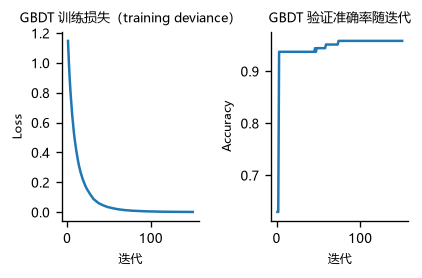

In [21]:
X, y = load_breast_cancer(return_X_y=True)
X = StandardScaler().fit_transform(X)
Xtr, Xv, ytr, yv = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

gb = GradientBoostingClassifier(n_estimators=150, random_state=42)
gb.fit(Xtr, ytr)

train_loss = np.array(gb.train_score_)
staged_va = [accuracy_score(yv, p) for p in gb.staged_predict(Xv)]

fig, ax = plt.subplots(1, 2, figsize=(8, 3.3))
ax[0].plot(np.arange(1, len(train_loss) + 1), train_loss)
ax[0].set_title("GBDT 训练损失（training deviance）")
ax[0].set_xlabel("迭代")
ax[0].set_ylabel("Loss")
ax[1].plot(np.arange(1, len(staged_va) + 1), staged_va)
ax[1].set_title("GBDT 验证准确率随迭代")
ax[1].set_xlabel("迭代")
ax[1].set_ylabel("Accuracy")
save_fig("20_gbdt")
plt.close(fig)


## 21. K-Means 聚类

目标是最小化类内平方和：

\[
\sum_{i=1}^N \left\|x_i-\mu_{c_i}\right\|^2
\]

**优缺点**：
- 优点：实现简单、解释直观
- 缺点：需先定K、对初值敏感、倾向球形簇


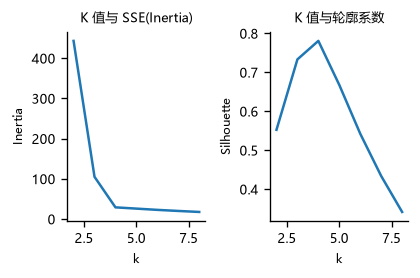

In [22]:
X, _ = make_blobs(n_samples=420, centers=4, cluster_std=1.1, random_state=42)
X = StandardScaler().fit_transform(X)
ks = np.arange(2, 9)
inertia = []
sil = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    if len(np.unique(labels)) > 1:
        sil.append(silhouette_score(X, labels))
    else:
        sil.append(np.nan)

k_best = ks[np.nanargmin(np.array(inertia))]
km = KMeans(n_clusters=k_best, random_state=42, n_init=10).fit(X)

fig, ax = plt.subplots(1, 2, figsize=(8, 3.2))
ax[0].plot(ks, inertia)
ax[0].set_title("K 值与 SSE(Inertia)")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")
ax[1].plot(ks, sil)
ax[1].set_title("K 值与轮廓系数")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette")
save_fig("21_kmeans")
plt.close(fig)


## 22. 关系图：主流模型生态关系图

将常见算法按“基础单元-序列模型-集成模型-无监督”分组。

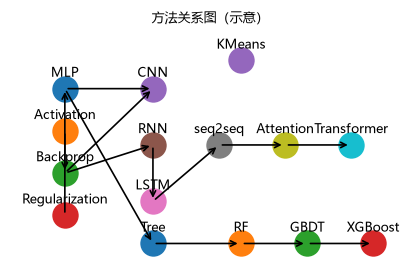

In [23]:
nodes = {
    "MLP": (0.20, 0.75),
    "Activation": (0.20, 0.60),
    "Backprop": (0.20, 0.45),
    "Regularization": (0.20, 0.30),
    "CNN": (0.40, 0.75),
    "RNN": (0.40, 0.55),
    "LSTM": (0.40, 0.35),
    "seq2seq": (0.55, 0.55),
    "Attention": (0.70, 0.55),
    "Transformer": (0.85, 0.55),
    "Tree": (0.40, 0.20),
    "RF": (0.60, 0.20),
    "GBDT": (0.75, 0.20),
    "XGBoost": (0.90, 0.20),
    "KMeans": (0.60, 0.85),
}
edges = [
    ("MLP", "CNN"),
    ("Activation", "Backprop"),
    ("Backprop", "RNN"),
    ("Backprop", "CNN"),
    ("RNN", "LSTM"),
    ("LSTM", "seq2seq"),
    ("seq2seq", "Attention"),
    ("Attention", "Transformer"),
    ("Regularization", "MLP"),
    ("MLP", "Tree"),
    ("Tree", "RF"),
    ("RF", "GBDT"),
    ("GBDT", "XGBoost"),
    ("RF", "Ensemble"),
]

fig, ax = plt.subplots(figsize=(9, 5.5))
for n, (x, y) in nodes.items():
    ax.scatter(x, y, s=220)
    ax.text(x, y + 0.03, n, ha="center", va="bottom", fontsize=8)
for a, b in edges:
    if a in nodes and b in nodes:
        xa, ya = nodes[a]
        xb, yb = nodes[b]
        ax.annotate(
            "",
            xy=(xb, yb),
            xytext=(xa, ya),
            arrowprops=dict(arrowstyle="->", lw=1.0),
        )
ax.set_xlim(0.08, 0.98)
ax.set_ylim(0.12, 0.95)
ax.set_title("方法关系图（示意）")
ax.axis("off")
save_fig("22_relation")
plt.close(fig)
